In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

Q. After loading the datasets, what is the structure of each dataset in terms of rows, colums, and data types?

In [2]:
data_confirmed = pd.read_csv("covid_19_confirmed_v1_lyst1747728690432.csv")
print(data_confirmed.head())

  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   
3            NaN        Andorra  42.50630   1.521800        0        0   
4            NaN         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  5/20/21  5/21/21  5/22/21  \
0        0        0        0        0  ...    64575    65080    65486   
1        0        0        0        0  ...   132118   132153   132176   
2        0        0        0        0  ...   126156   126434   126651   
3        0        0        0        0  ...    13569    13569    13569   
4        0        0        0        0  ...    31661    31909    32149   

   5/23/21  5/24/21  5/25/21  5/26/21  5/27/21  5/28/21  5/29/21  
0    65728    66275    66903    67743    68366   

In [3]:
data_deaths = pd.read_csv("covid_19_deaths_v1_lyst1747728711771.csv")
print(data_deaths.head())

          Column1         Column2   Column3    Column4  Column5  Column6  \
0  Province/State  Country/Region       Lat       Long  1/22/20  1/23/20   
1             NaN     Afghanistan  33.93911  67.709953        0        0   
2             NaN         Albania   41.1533    20.1683        0        0   
3             NaN         Algeria   28.0339     1.6596        0        0   
4             NaN         Andorra   42.5063     1.5218        0        0   

   Column7  Column8  Column9 Column10  ... Column489 Column490 Column491  \
0  1/24/20  1/25/20  1/26/20  1/27/20  ...   5/20/21   5/21/21   5/22/21   
1        0        0        0        0  ...      2772      2782      2792   
2        0        0        0        0  ...      2440      2441      2442   
3        0        0        0        0  ...      3401      3405      3411   
4        0        0        0        0  ...       127       127       127   

  Column492 Column493 Column494 Column495 Column496 Column497 Column498  
0   5/23/21 

In [4]:
data_recovered =  pd.read_csv("covid_19_recovered_v1_lyst1747728719904.csv")
print(data_recovered.head())

          Column1         Column2   Column3    Column4  Column5  Column6  \
0  Province/State  Country/Region       Lat       Long  1/22/20  1/23/20   
1             NaN     Afghanistan  33.93911  67.709953        0        0   
2             NaN         Albania   41.1533    20.1683        0        0   
3             NaN         Algeria   28.0339     1.6596        0        0   
4             NaN         Andorra   42.5063     1.5218        0        0   

   Column7  Column8  Column9 Column10  ... Column489 Column490 Column491  \
0  1/24/20  1/25/20  1/26/20  1/27/20  ...   5/20/21   5/21/21   5/22/21   
1        0        0        0        0  ...     55687     55790     55889   
2        0        0        0        0  ...    127869    128425    128601   
3        0        0        0        0  ...     87902     88066     88208   
4        0        0        0        0  ...     13234     13234     13234   

  Column492 Column493 Column494 Column495 Column496 Column497 Column498  
0   5/23/21 

Data Exploration

In [5]:
print(data_confirmed.info())
print(data_deaths.info())
print(data_recovered.info())

<class 'pandas.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(2), int64(494), str(2)
memory usage: 1.1 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Columns: 498 entries, Column1 to Column498
dtypes: str(498)
memory usage: 1.3 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Columns: 498 entries, Column1 to Column498
dtypes: str(498)
memory usage: 1.4 MB
None


Q. Generate plots of confirmed cases over time for the top countries.

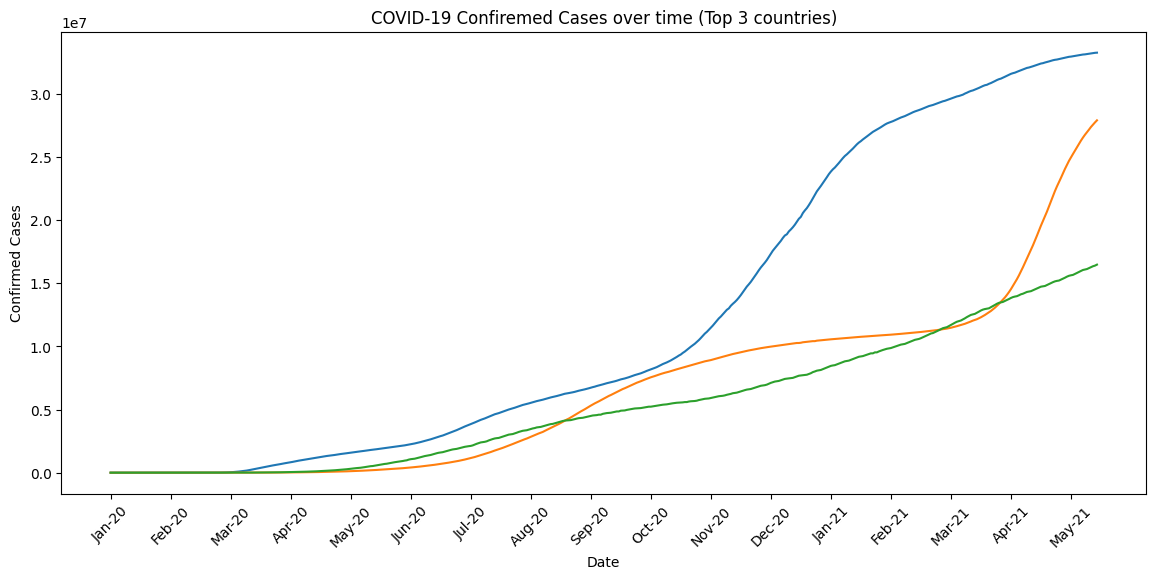

In [6]:
data_confirmed = pd.read_csv("covid_19_confirmed_v1_lyst1747728690432.csv")

confirmed_plot = data_confirmed.copy()  # Created a copy of the original dataframe

confirmed_plot = confirmed_plot.groupby("Country/Region").sum(numeric_only=True)    #Groupby of country
confirmed_plot = confirmed_plot.drop(columns=["Lat", "Long"], errors="ignore") #Removed unnecessary cols

dates = pd.to_datetime(confirmed_plot.columns, format="%m/%d/%y")

new_data = confirmed_plot.columns[-1]   #Top 3 countries based on new data
top3 = confirmed_plot[new_data].nlargest(3).index

plt.figure(figsize=(14,6))
plt.title("COVID-19 Confiremed Cases over time (Top 3 countries)")

for country in top3:
    plt.plot(dates, confirmed_plot.loc[country], label=country)

plt.xticks(dates[::30],                     #Displayed one label every 30 days
           dates[::30].strftime('%b-%y'),
           rotation=45)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

Q. Generate plots of confirmed cases over time for china

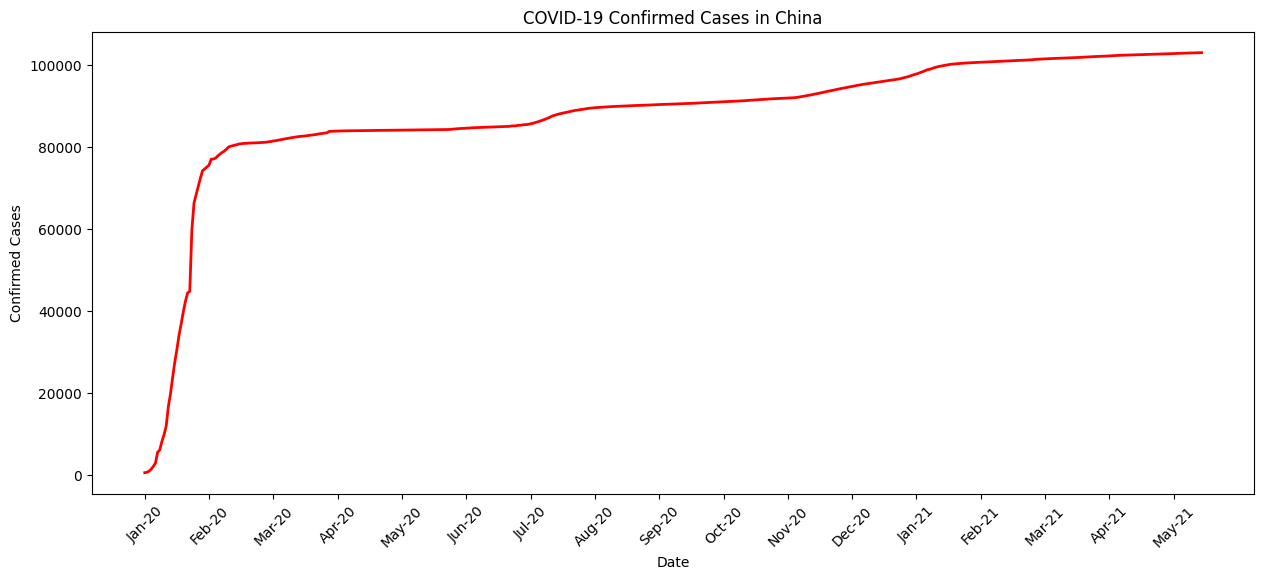

In [7]:
plt.figure(figsize=(15,6))
plt.title("COVID-19 Confirmed Cases in China")
plt.plot(dates, confirmed_plot.loc["China"], color="red", linewidth=2)
plt.xticks(dates[::30],                     #Displayed one label every 30 days
           dates[::30].strftime('%b-%y'),
           rotation=45)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

Handling Missing Data

Q. Identify these missing values and replace them using a suitable imputation method, such as forward filling, for time-series data.

In [8]:
data_confirmed.isnull().sum().sum() #Missing value count

np.int64(194)

In [9]:
data_deaths.isnull().sum().sum()
data_deaths.ffill(inplace=True)

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,Province/State,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
2,Province/State,Albania,41.1533,20.1683,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
3,Province/State,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
4,Province/State,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,Turks and Caicos Islands,Vietnam,14.058324,108.277199,0,0,0,0,0,0,...,39,41,42,43,44,44,45,46,47,47
273,Turks and Caicos Islands,West Bank and Gaza,31.9522,35.2332,0,0,0,0,0,0,...,3448,3452,3459,3459,3470,3480,3483,3483,3489,3492
274,Turks and Caicos Islands,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,1301,1302,1304,1307,1310,1311,1313,1315,1316,1319
275,Turks and Caicos Islands,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,1265,1266,1267,1268,1271,1271,1273,1275,1275,1276


In [10]:
data_recovered.isnull().sum().sum()
data_recovered.ffill(inplace=True)

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,Province/State,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
2,Province/State,Albania,41.1533,20.1683,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
3,Province/State,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
4,Province/State,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,Turks and Caicos Islands,Vietnam,14.058324,108.277199,0,0,0,0,0,0,...,2687,2689,2721,2721,2794,2794,2853,2853,2896,2896
258,Turks and Caicos Islands,West Bank and Gaza,31.9522,35.2332,0,0,0,0,0,0,...,295643,296901,297201,297201,298502,299024,299559,299559,300125,300524
259,Turks and Caicos Islands,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,3159,3179,3201,3245,3260,3273,3306,3339,3375,3399
260,Turks and Caicos Islands,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,90955,91019,91102,91156,91200,91221,91239,91321,91443,91594


Data Cleaning and preparation

Q. Replace blank values in the province column with "All Provinces"

In [11]:
data_confirmed.replace("","All Provinces", inplace=True)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,NaN,Vietnam,14.058324,108.277199,0,2,2,2,2,2,...,4809,4941,5119,5275,5404,5931,6086,6356,6396,6908
272,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,304532,304968,305201,305201,305777,306334,306795,306795,307569,307838
273,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,6613,6632,6649,6658,6662,6670,6688,6696,6723,6731
274,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,92754,92920,93106,93201,93279,93428,93627,93947,94430,94751


Independent Dataset Analysis

Q. Analyze the peak number of daily new cases in Germany, France, and Italy. Which country experienced the highest single-day surge, and when did it occur? 

In [12]:
daily_cases = confirmed_plot.diff(axis=1)    # Calculate daily new cases
daily_cases = daily_cases.fillna(0)

peak_cases = daily_cases.max(axis=1)    # Replace first day's NaN with 0
peak_cases = daily_cases.idxmax(axis=1) 

countries = ["Germany", "France", "Italy"]

for country in countries:
    peak_cases = daily_cases.loc[country].max()
    peak_dates = daily_cases.loc[country].idxmax()
    
    print(f"{country}")
    print(f"Peak Daily New Cases : {int(peak_cases)}")
    print(f"Date : {peak_dates}")
    print("-"*40)

results = []

for country in countries:
    peak_dates = daily_cases.loc[country].max()
    peak_dates = daily_cases.loc[country].idxmax()
    
    results.append([country, peak_cases, peak_dates])
    
peak_df = pd.DataFrame(results, columns=["Country", "Peak Cases", "Peak Date"])
highest = peak_df.loc[peak_df["Peak Cases"].idxmax()]

print("\nHighest Single-Day Surge")
print(f"Country : {highest['Country']}")
print(f"Cases : {highest['Peak Cases']}")
print(f"Date : {highest['Peak Date']}")

Germany
Peak Daily New Cases : 49044
Date : 12/30/20
----------------------------------------
France
Peak Daily New Cases : 117900
Date : 4/11/21
----------------------------------------
Italy
Peak Daily New Cases : 40902
Date : 11/13/20
----------------------------------------

Highest Single-Day Surge
Country : Germany
Cases : 40902.0
Date : 12/30/20


Q. Compare the recovery rates(recoveries/confirmed cases) between Canada and Australia as of December 31, 2020. Which country showed better management of the pandemic according to this metric?

In [ ]:
recovered_plot = data_recovered.copy()

recovered_plot.columns = recovered_plot.iloc[0] # Used the first row as column names
recovered_plot = recovered_plot[1:].reset_index(drop=True)  # Remove the first row

recovered_plot["Lat"] = pd.to_numeric(recovered_plot["Lat"],errors="coerce")    # Convert Lat and Long to numeric
recovered_plot["Long"] = pd.to_numeric(recovered_plot["Long"], errors="coerce")

date_cols = recovered_plot.columns[4:]  # Converted all date columns to numeric
recovered_plot[date_cols] = recovered_plot[date_cols].apply(pd.to_numeric, errors="coerce")

recovered_plot = recovered_plot.groupby("Country/Region").sum(numeric_only=True)
recovered_plot = recovered_plot.drop(columns=["Lat","Long"], errors='ignore')

confirmed_plot = confirmed_plot.groupby("Country/Region").sum(numeric_only=True)    #Groupby of country
confirmed_plot = confirmed_plot.drop(columns=["Lat", "Long"], errors="ignore") #Removed unnecessary cols

countries = ["Canada", "Australia"]
date = "12/31/20"

for country in countries:
    confirmed_cases = confirmed_plot.loc[country, date]
    recovered_cases = recovered_plot.loc[country, date]
    
    recovery_rate = (recovered_cases / confirmed_cases)*100
    
    print(f"{country}")
    print(f"Confirmed Cases : {confirmed_cases}")
    print(f"Recovered Cases : {recovered_cases}")
    print(f"Recovery Rate : {recovery_rate:.2f}%")
    print("-"*40)
    
compare = pd.DataFrame(columns=["Country", "Recovery Rate"])

for country in countries:
    rate = (recovered_plot.loc[country, date] / confirmed_plot.loc[country, date])* 100
    compare.loc[len(compare)] = [country, rate]
    

best = compare.loc[compare["Recovery Rate"].idxmax()]

print("\nBetter Pandemic Management")
print(f"Country : {best['Country']}")
print(f"Recovery Rate : {best['Recovery Rate']:.2f}%")



Canada
Confirmed Cases : 584409
Recovered Cases : 493638
Recovery Rate : 84.47%
----------------------------------------
Australia
Confirmed Cases : 28425
Recovered Cases : 22565
Recovery Rate : 79.38%
----------------------------------------

Better Pandemic Management
Country : Canada
Recovery Rate : 84.47%


Q. What is the distribution of death rates (deaths/confirmed cases) among provinces in Canada? Identify the province with the highest and the lowest death rates as of the latest data point.

In [39]:
# Reloaded the datasets
confirmed_province = pd.read_csv("covid_19_confirmed_v1_lyst1747728690432.csv")
death_province = pd.read_csv("covid_19_deaths_v1_lyst1747728711771.csv")

# Used first row as header
death_province.columns = death_province.iloc[0]
death_province = death_province.iloc[1:].reset_index(drop=True)

latest_data = confirmed_province.columns[-1]

confirmed_canada = confirmed_province[
    confirmed_province["Country/Region"] == "Canada"
][["Province/State", latest_data]]

death_canada = death_province[
    death_province["Country/Region"] == "Canada"
][["Province/State", latest_data]]

canada = confirmed_canada.merge(
    death_canada,
    on="Province/State",
    suffixes=("_Confirmed", "_Deaths")
)

# Converted to numeric
canada[f"{latest_data}_Confirmed"] = pd.to_numeric(
    canada[f"{latest_data}_Confirmed"], errors="coerce"
)
canada[f"{latest_data}_Deaths"] = pd.to_numeric(
    canada[f"{latest_data}_Deaths"], errors="coerce"
)

# Removed rows with 0 confirmed cases
canada = canada[canada[f"{latest_data}_Confirmed"] > 0]

# Calculated death rate
canada["Death Rate (%)"] = (
    canada[f"{latest_data}_Deaths"] /
    canada[f"{latest_data}_Confirmed"]
) * 100

highest = canada.loc[canada["Death Rate (%)"].idxmax()]
lowest = canada.loc[canada["Death Rate (%)"].idxmin()]

print("\nHighest Death Rate")
print(highest[["Province/State", "Death Rate (%)"]])
print("-"*40)

print("\nLowest Death Rate")
print(lowest[["Province/State", "Death Rate (%)"]])
print("-"*40)

print("\nDistribution")
print(canada.sort_values("Death Rate (%)")[["Province/State", "Death Rate (%)"]])


Highest Death Rate
Province/State      Quebec
Death Rate (%)    3.008969
Name: 12, dtype: object
----------------------------------------

Lowest Death Rate
Province/State    Grand Princess
Death Rate (%)               0.0
Name: 3, dtype: object
----------------------------------------

Distribution
               Province/State  Death Rate (%)
3              Grand Princess        0.000000
7       Northwest Territories        0.000000
13     Repatriated Travellers        0.000000
11       Prince Edward Island        0.000000
6   Newfoundland and Labrador        0.460829
9                     Nunavut        0.617284
0                     Alberta        0.975954
14               Saskatchewan        1.155733
1            British Columbia        1.178429
8                 Nova Scotia        1.518987
10                    Ontario        1.619323
5               New Brunswick        1.962574
4                    Manitoba        2.069348
15                      Yukon        2.380952
12      